# Step 4: Baseline Model (TF-IDF + Logistic Regression)
This baseline gives us a fast, cheap model to set the bar for the transformer.


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load splits
try:
    train_df = pd.read_csv("data/processed/train.csv")
    val_df = pd.read_csv("data/processed/validation.csv")
    test_df = pd.read_csv("data/processed/test.csv")
except FileNotFoundError:
    print("Processed data not found. Please run 02_Cleaning_Split.ipynb first.")
    raise


In [3]:
# TF-IDF Vectorization
# Using a small manual Hindi stopword list since there is no standard NLTK one readily available
hindi_stopwords = ["के", "में", "की", "है", "और", "को", "से", "हैं", "कि", "का", "लिए", "पर", "यह"] 

vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words=hindi_stopwords, max_features=10000)
X_train = vectorizer.fit_transform(train_df['text'].fillna(""))
X_val = vectorizer.transform(val_df['text'].fillna(""))

y_train = train_df['label']
y_val = val_df['label']


In [4]:
# Train Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='macro')

print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation Macro-F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Validation Accuracy: 0.7897
Validation Macro-F1: 0.7748

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83      1480
           1       0.82      0.64      0.72      1055

    accuracy                           0.79      2535
   macro avg       0.80      0.77      0.77      2535
weighted avg       0.79      0.79      0.78      2535



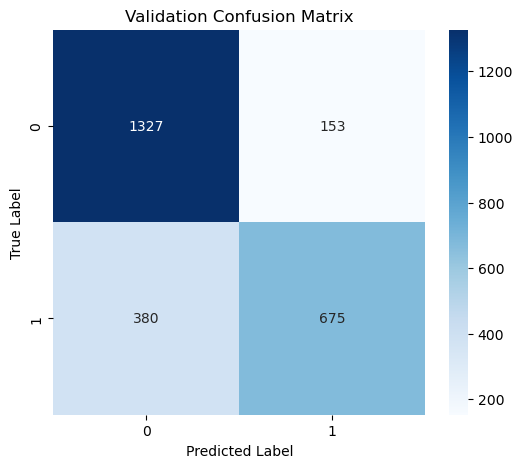

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
